## 📎 Code this notebook uses
*(how to run + which code each step uses → [`README.md`](README.md);  file-by-file code reference → [`CODE_MANUAL.pdf`](CODE_MANUAL.pdf))*

- **Figures — `pipeline/figures/`:** `make_context_map_figure`, `make_intro_figures`, `make_apollo_timeline_letter`, `make_letter_figures`


# 01 — Methods figures

This notebook builds the figures and parameter tables for the **Methods**
section. Nothing here is a heavy computation — it draws schematics, a map,
a timeline, and prints the fixed inputs.

**How each section works:** a code cell imports a generator from
`pipeline/figures/`, calls it (which writes a PDF into
`results/figures/`), and then `show_fig(...)` displays that PDF
inline so you can see it immediately. Run the cells top to bottom.

| Output | Generator |
|---|---|
| Fig 1 — Probe schematic + published K(z) | `pipeline/figures/make_intro_figures.py` |
| Fig 2 — Apollo landing-site context map | `pipeline/figures/make_context_map_figure.py` |
| Fig 3 — Apollo HFE meter-scale-sensor timeline | `pipeline/figures/make_apollo_timeline_letter.py` |
| Fig 4 — Diurnal amplitude vs depth (borestem diagnostic) | `pipeline/figures/make_letter_figures.py::fig_amplitude_vs_depth` |
| Table 1 — Fixed solver inputs | inlined below |

All figures overwrite the shipped PDFs in `results/figures/`.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'pipeline' / 'figures'))
print('Project root:', ROOT)
FIGS = ROOT.parent / "figures"   # shared top-level figures/ (what documents read)

from IPython.display import Image, display
import io
def show_fig(name):
    """Display a figure inline. Prefers the PNG companion; falls back to
    rendering the PDF on the fly via pymupdf if no PNG exists."""
    stem = name.replace('.pdf','').replace('.png','')
    png = FIGS / f"{stem}.png"
    if png.exists():
        display(Image(filename=str(png))); return
    pdf = FIGS / f"{stem}.pdf"
    if pdf.exists():
        try:
            import fitz
            pix = fitz.open(str(pdf))[0].get_pixmap(dpi=140)
            display(Image(data=pix.tobytes("png")))
        except Exception as e:
            print(f"  (couldn't render {pdf.name}: {e})")
    else:
        print(f"(no figure file for {stem})")


Project root: /Users/rp3gregorio/Developer/Lunar-Clean/github/code


## Fig 1 — Probe schematic + published K(z)

Two panels orienting the reader: a schematic of how the HFE probe sits in
the drilled borehole (which sensor is at which depth), and the Hayne
(2017) thermal-conductivity profile K(z), which rises steeply from a very
low surface value to its deep value over the e-folding depth H.

**What to look for:** how shallow the steep part of K(z) is — almost all
the variation happens in the top ~10 cm, which is why a fine near-surface
grid matters.

`make_intro_figures.py` (`fig_intro_probe`) draws this two-panel
schematic and writes `fig_intro_probe.pdf`.

  -> /Users/rp3gregorio/Developer/Lunar-Clean/github/code/../figures/fig_intro_probe.pdf


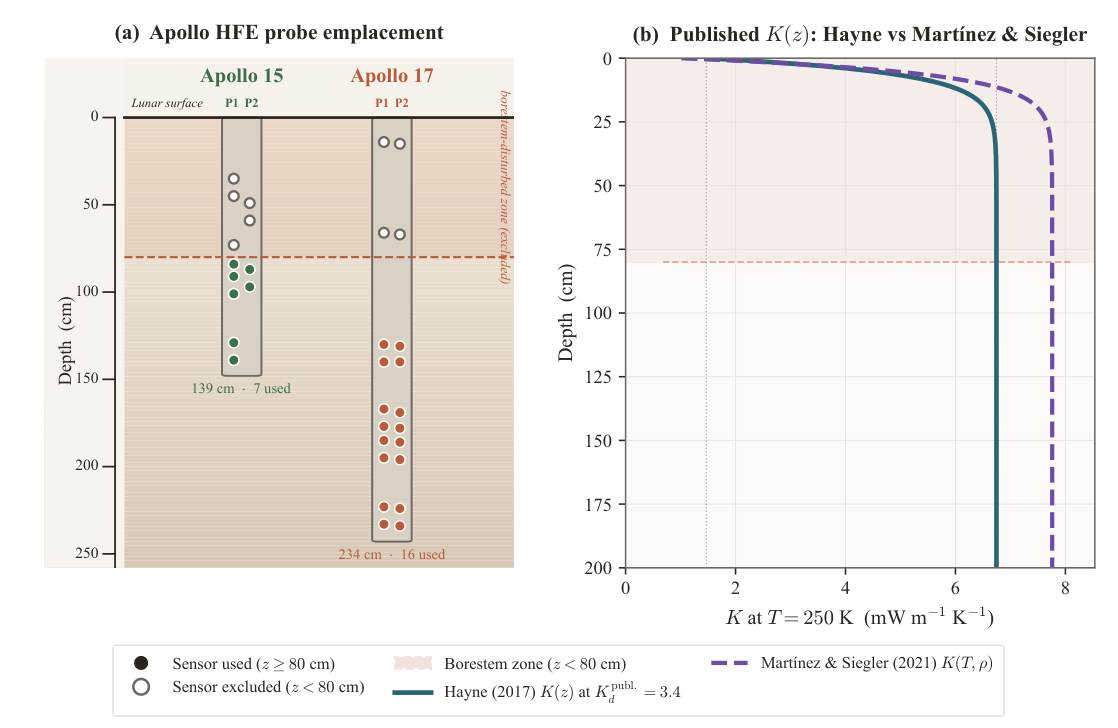

In [2]:
import make_intro_figures
make_intro_figures.fig_intro_probe()
show_fig('fig_intro_probe')

## Fig 2 — Apollo landing-site context map

A lunar near-side map marking the two boreholes: **Apollo 15** at Hadley
Rille (26°N) and **Apollo 17** at Taurus–Littrow (20°N). Context for why
the two sites have different regolith and slightly different illumination.

`make_context_map_figure.py` renders the near-side basemap, marks the
two boreholes, and writes `fig_context_map.pdf`.

  -> /Users/rp3gregorio/Developer/Lunar-Clean/github/code/../figures/fig_context_map.pdf


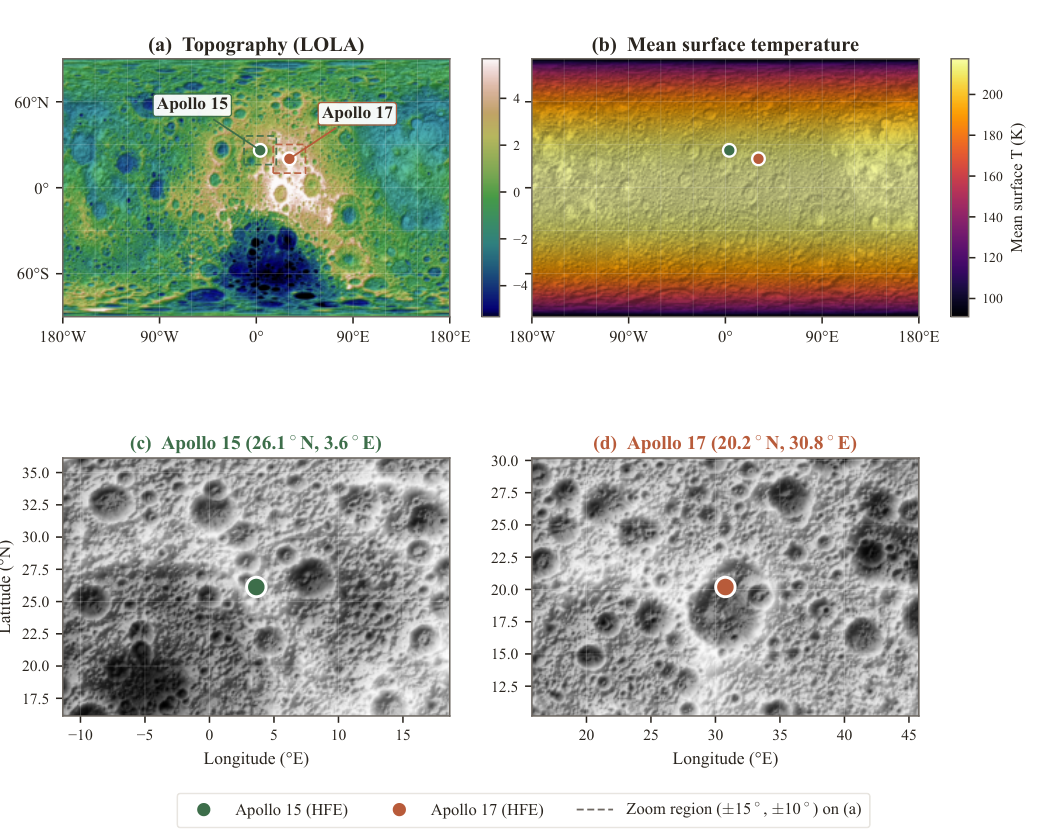

In [3]:
import make_context_map_figure
make_context_map_figure.main()
show_fig('fig_context_map')

## Fig 3 — Apollo HFE meter-scale-sensor timeline

The 1971–1977 temperature record for each deep sensor. Early on the
sensors are still equilibrating after emplacement; later they settle into
a steady seasonal cycle. We fit only the **stable window** (the settled
portion), and this figure shows how that window is chosen per sensor.

**What to look for:** the flattening of each trace — the retrieval uses
the late, stable part, not the noisy startup transient.

`make_apollo_timeline_letter.py` reads the restored HFE record, picks
each sensor's stable window, and writes `fig_apollo_timeline_probes.pdf`.

Lunar-V2 notebook bootstrap
  python : /Users/rp3gregorio/Developer/Lunar-Clean/github/.venv/bin/python
  repo   : /Users/rp3gregorio/Developer/Lunar-Clean/github/code


  deps   : all present
  lunar  : /Users/rp3gregorio/Developer/Lunar-Clean/github/code/src/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


  -> fig_apollo_timeline_probes.pdf (redrawn from live data; faithful to the archived original, see module docstring)


  -> fig_apollo_timeline_a15.pdf


  -> fig_apollo_timeline_a17.pdf


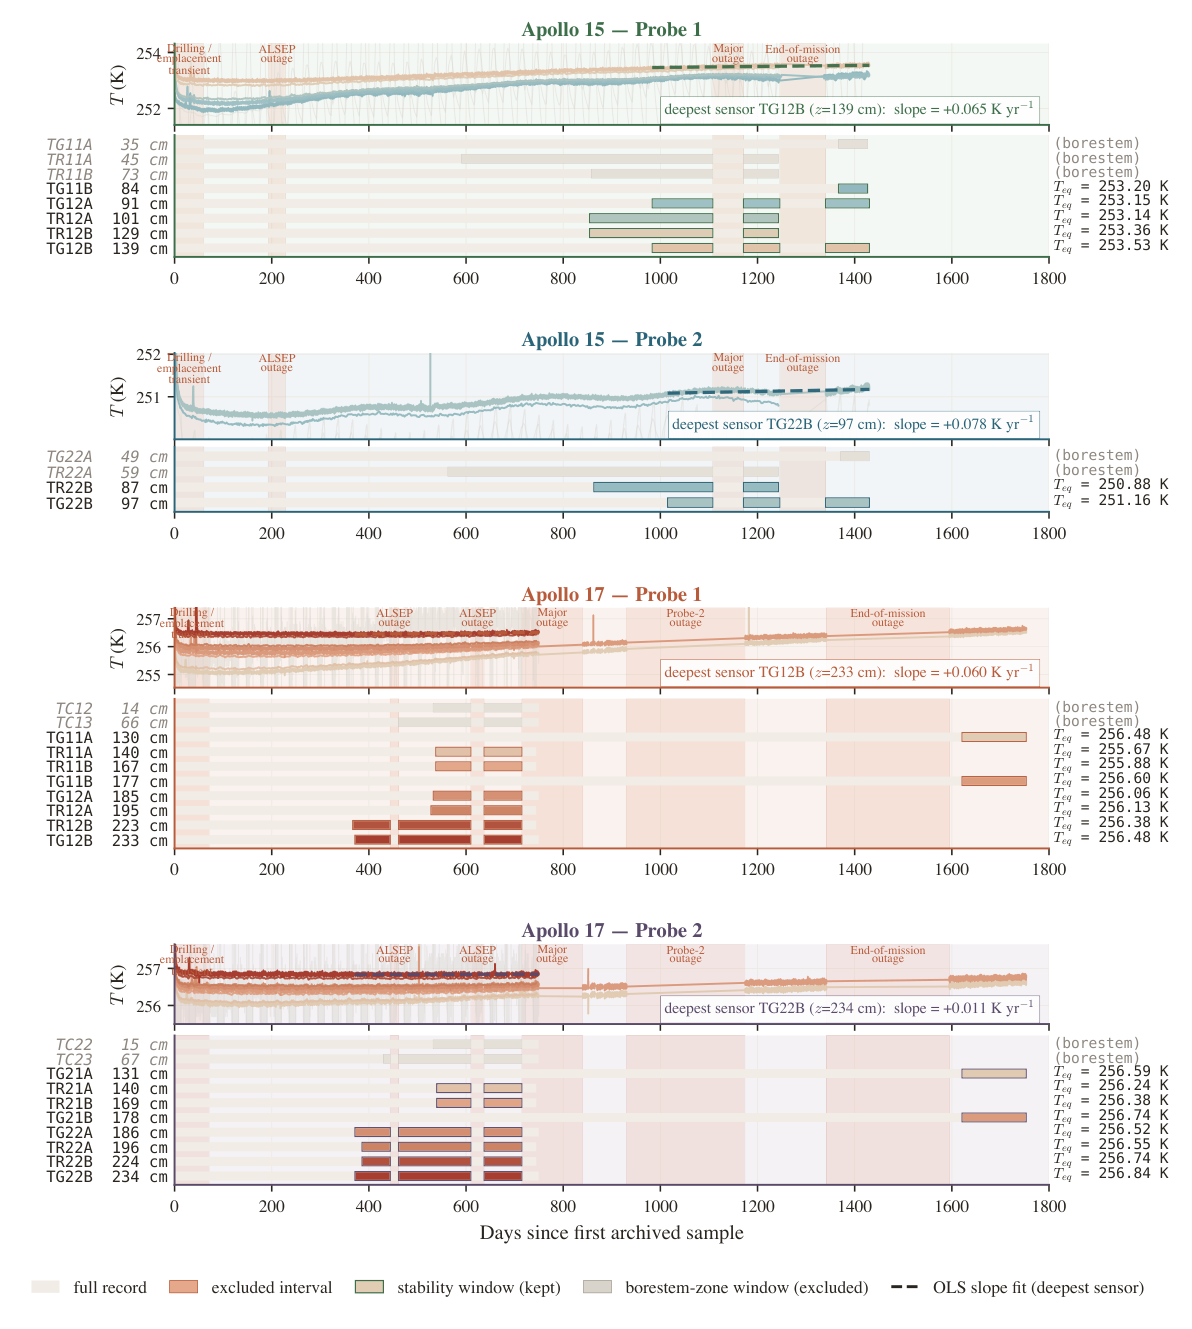

In [4]:
import make_apollo_timeline_letter
make_apollo_timeline_letter.main()   # -> figures/fig_apollo_timeline_probes.pdf (the letter's Fig 3)
show_fig('fig_apollo_timeline_probes')

## Fig 4 — Diurnal amplitude vs depth (the borestem diagnostic)

The size of the day–night temperature swing as a function of depth. It
should decay smoothly with depth (heat diffusion damps the surface wave).
Above ~80 cm the metal borestem short-circuits heat and **distorts** that
clean decay.

**What to look for:** the kink/excess amplitude in the shallowest sensors
— that distortion is exactly why we discard everything above the 80 cm
borestem cut.

`make_letter_figures.py` (`fig_amplitude_vs_depth`) computes the
per-sensor diurnal amplitude and writes `fig_amplitude_vs_depth.pdf`.

Lunar-V2 notebook bootstrap
  python : /Users/rp3gregorio/Developer/Lunar-Clean/github/.venv/bin/python
  repo   : /Users/rp3gregorio/Developer/Lunar-Clean/github/code
  deps   : all present
  lunar  : /Users/rp3gregorio/Developer/Lunar-Clean/github/code/src/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


  → /Users/rp3gregorio/Developer/Lunar-Clean/github/code/../figures/fig_amplitude_vs_depth.pdf


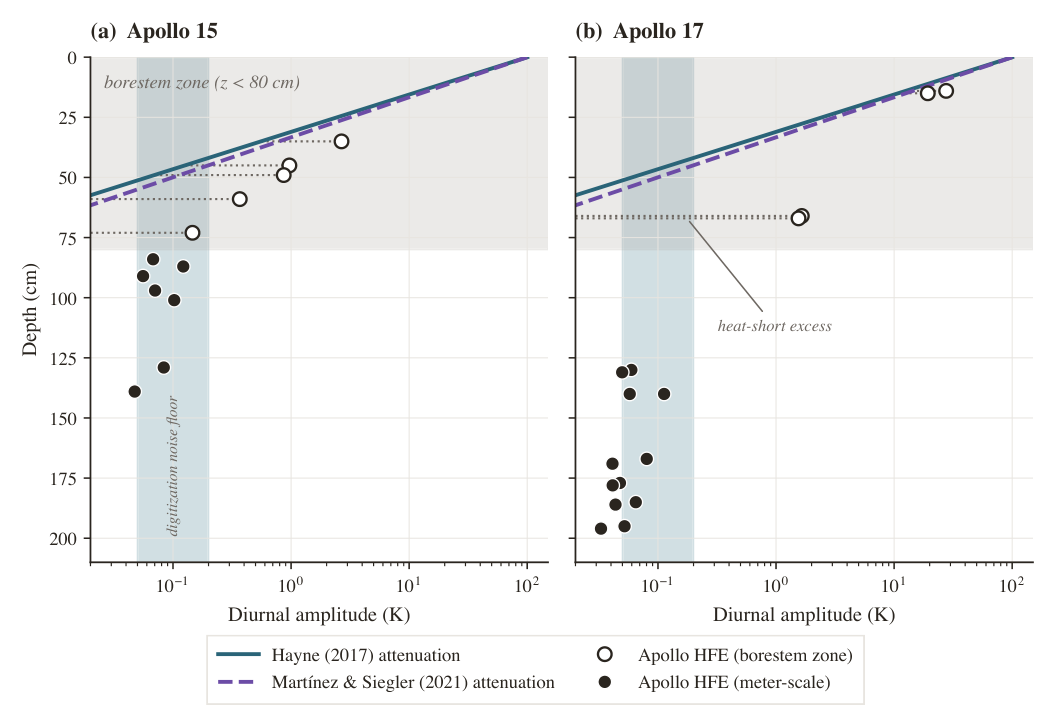

In [5]:
from make_letter_figures import fig_amplitude_vs_depth
fig_amplitude_vs_depth()
show_fig('fig_amplitude_vs_depth')

## Table 1 — Fixed inputs to the 1-D heat solver

The constants every run shares, built directly from `lunar.constants` so
the printed table can never disagree with what the solver actually uses.
These are *not* fitted — they are held fixed at their published values
while we retrieve K_d.

In [6]:
from lunar import constants as c
import pandas as pd
rows = [
    # (parameter, symbol, value, unit, source)
    ('Surface thermal conductivity',    'K_s',        f'{c.K_SURFACE:.2e}',    'W m^-1 K^-1', 'Hayne 2017'),
    ('Deep thermal conductivity (publ.)', 'K_d (publ.)', f'{c.K_DEEP:.2e}',     'W m^-1 K^-1', 'Hayne 2017'),
    ('K(z) transition e-folding depth', 'H',          f'{c.H_PARAMETER}',      'm',           'Hayne 2017'),
    ('Radiative coefficient',           'chi',        f'{c.CHI_RADIATIVE}',    'dimensionless', 'Hayne 2017'),
    ('Radiative normalisation T',       'T_ref',      f'{c.T_REFERENCE}',      'K',           'Hayne 2017'),
    ('Surface bulk density',            'rho_s',      f'{c.RHO_SURFACE}',      'kg m^-3',     'Hayne 2017'),
    ('Deep bulk density',               'rho_d',      f'{c.RHO_DEEP}',         'kg m^-3',     'Hayne 2017'),
    ('Stefan-Boltzmann constant',       'sigma',      f'{c.SIGMA_SB:.4e}',        'W m^-2 K^-4', 'CODATA'),
]
df = pd.DataFrame(rows, columns=['Parameter', 'Symbol', 'Value', 'Unit', 'Source'])
df

,Parameter,Symbol,Value,Unit,Source
0,Surface thermal conductivity,K_s,7.40e-04,W m^-1 K^-1,Hayne 2017
1,Deep thermal conductivity (publ.),K_d (publ.),3.40e-03,W m^-1 K^-1,Hayne 2017
2,K(z) transition e-folding depth,H,0.06,m,Hayne 2017
3,Radiative coefficient,chi,2.7,dimensionless,Hayne 2017
4,Radiative normalisation T,T_ref,350.0,K,Hayne 2017
5,Surface bulk density,rho_s,1100.0,kg m^-3,Hayne 2017
6,Deep bulk density,rho_d,1800.0,kg m^-3,Hayne 2017
7,Stefan-Boltzmann constant,sigma,5.6704e-08,W m^-2 K^-4,CODATA


### Site-specific inputs

The handful of numbers that differ between the two boreholes — latitude,
albedo, emissivity, the published basal heat flux Q_b, and the deepest
sensor depth. These come from `lunar/config.py` (`SITES`) and the cited
sources. The basal flux Q_b is held fixed during the K_d retrieval (the
paper's stated assumption).

In [7]:
from lunar.config import SITES
a15, a17 = SITES['A15'], SITES['A17']
site_rows = [
    ('Latitude',        'lat',   f"{a15['lat']:.2f} N",  f"{a17['lat']:.2f} N",  'Davies & Colvin 2000'),
    ('Longitude',       'lon',   f"{a15['lon']:.2f} E",  f"{a17['lon']:.2f} E",  'Davies & Colvin 2000'),
    ('Bond albedo',     'A',     f"{a15['albedo']:.4f}", f"{a17['albedo']:.4f}", 'fitted (joint retrieval, compute_joint_albedo_fit.py)'),
    ('Emissivity',      'eps',   f"{a15['emissivity']}", f"{a17['emissivity']}", 'Bandfield 2015'),
    ('Basal heat flux', 'Q_b',   f"{a15['Q_BASAL']*1e3:g} mW m^-2", f"{a17['Q_BASAL']*1e3:g} mW m^-2", 'Langseth 1976'),
    ('Deepest sensor',  'z_max', '139 cm',       '234 cm',   'Nagihara 2018'),
]
df_site = pd.DataFrame(site_rows, columns=['Parameter', 'Symbol', 'Apollo 15', 'Apollo 17', 'Source'])
df_site

,Parameter,Symbol,Apollo 15,Apollo 17,Source
0,Latitude,lat,26.13 N,20.19 N,Davies & Colvin 2000
1,Longitude,lon,3.63 E,30.77 E,Davies & Colvin 2000
2,Bond albedo,A,0.1363,0.1375,"fitted (joint retrieval, compute_joint_albedo_..."
3,Emissivity,eps,0.95,0.95,Bandfield 2015
4,Basal heat flux,Q_b,21 mW m^-2,16 mW m^-2,Langseth 1976
5,Deepest sensor,z_max,139 cm,234 cm,Nagihara 2018
